Enter number of epochs: 5
Enter batch size: 32
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9265 - loss: 0.2588
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9654 - loss: 0.1158
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9762 - loss: 0.0790
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9815 - loss: 0.0590
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9859 - loss: 0.0448
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9760 - loss: 0.0794

Test Accuracy:
0.9760000109672546
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Predicted Digit:
7

Actual Digit:
7


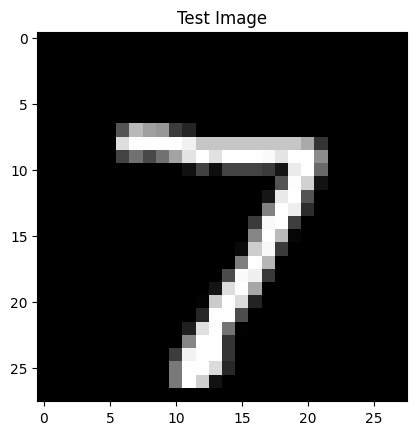

In [1]:
# Image Classifier using TensorFlow 2.0

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# Step 1: Take User Input
# -----------------------------------

epochs = int(input("Enter number of epochs: "))
batch_size = int(input("Enter batch size: "))

# -----------------------------------
# Step 2: Load Dataset
# -----------------------------------

mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# -----------------------------------
# Step 3: Normalize Data
# -----------------------------------

x_train = x_train / 255.0
x_test = x_test / 255.0

# -----------------------------------
# Step 4: Build Neural Network Model
# -----------------------------------

model = tf.keras.models.Sequential([

    tf.keras.Input(shape=(28, 28)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

# -----------------------------------
# Step 5: Compile Model
# -----------------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------------
# Step 6: Train Model
# -----------------------------------

history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size
)

# -----------------------------------
# Step 7: Evaluate Model
# -----------------------------------

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("\nTest Accuracy:")
print(test_accuracy)

# -----------------------------------
# Step 8: Predict Sample Image
# -----------------------------------

prediction = model.predict(x_test)

predicted_label = np.argmax(prediction[0])

print("\nPredicted Digit:")
print(predicted_label)

print("\nActual Digit:")
print(y_test[0])

# -----------------------------------
# Step 9: Display Image
# -----------------------------------

plt.imshow(x_test[0], cmap='gray')

plt.title("Test Image")

plt.show()